<a href="https://colab.research.google.com/github/Thujaina/ECG-Classification---MobileNet/blob/main/sparse_categorical_CE_mobilenet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn


In [2]:
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from keras.layers import (
    Conv1D,
    DepthwiseConv1D,
    Dense,
    BatchNormalization,
    GlobalAveragePooling1D,
    Dropout,
    Input,
    ReLU
)
from keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

from google.colab import drive

warnings.filterwarnings("ignore")

SEED = 42
N_CLASSES = 5
SIGNAL_LENGTH = 187

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [3]:
drive.mount('/content/drive')

TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Mounted at /content/drive
Train shape: (87554, 188)
Test shape: (21892, 188)


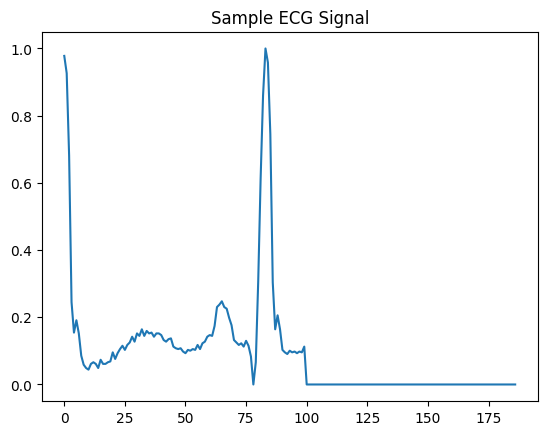

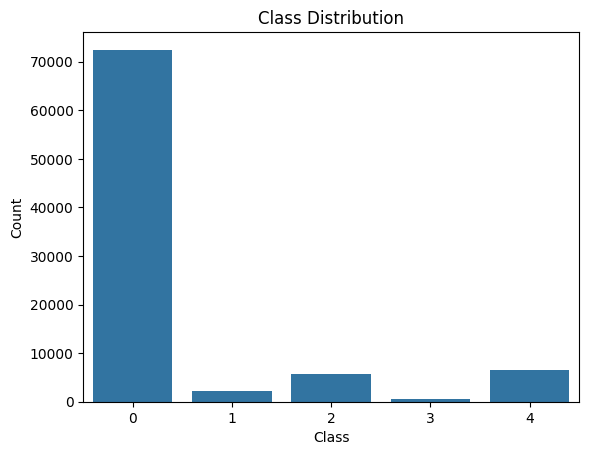

Train Missing: 0
Test Missing : 0


In [4]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

counts = train.iloc[:, -1].value_counts().sort_index()

sns.barplot(x=[0, 1, 2, 3, 4], y=counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

print("Train Missing:", train.isna().sum().sum())
print("Test Missing :", test.isna().sum().sum())


In [5]:
X = train.iloc[:, :-1].values.astype(np.float32)
y = train.iloc[:, -1].values.astype(np.int32)

X_test_raw = test.iloc[:, :-1].values.astype(np.float32)
y_test = test.iloc[:, -1].values.astype(np.int32)

def scale_smote_reshape(X_train_part, y_train_part, X_val_part=None):
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_part)

    smote = SMOTE(random_state=SEED)
    X_train_balanced, y_train_balanced = smote.fit_resample(
        X_train_scaled,
        y_train_part
    )

    X_train_balanced = X_train_balanced.reshape(-1, SIGNAL_LENGTH, 1)

    if X_val_part is None:
        return X_train_balanced, y_train_balanced, scaler

    X_val_scaled = scaler.transform(X_val_part)
    X_val_scaled = X_val_scaled.reshape(-1, SIGNAL_LENGTH, 1)

    return X_train_balanced, y_train_balanced, X_val_scaled, scaler


In [6]:
def mobilenet_block(x, filters, stride=1):

    x = DepthwiseConv1D(
        kernel_size=3,
        strides=stride,
        padding="same",
        use_bias=False
    )(x)

    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(
        filters,
        kernel_size=1,
        padding="same",
        use_bias=False
    )(x)

    x = BatchNormalization()(x)
    x = ReLU()(x)

    return x


def mobilenet_ecg(dropout_rate=0.55):

    inputs = Input(shape=(SIGNAL_LENGTH, 1))

    x = Conv1D(
        32,
        kernel_size=3,
        padding="same",
        use_bias=False
    )(inputs)

    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = mobilenet_block(x, 64)

    x = mobilenet_block(
        x,
        128,
        stride=2
    )

    x = mobilenet_block(x, 128)

    x = mobilenet_block(
        x,
        256,
        stride=2
    )

    x = mobilenet_block(x, 256)

    x = GlobalAveragePooling1D()(x)

    x = Dense(
        128,
        activation="relu"
    )(x)

    x = Dropout(dropout_rate)(x)

    outputs = Dense(N_CLASSES)(x)

    model = Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer=Adam(
            learning_rate=1e-3
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True
        ),
        metrics=["accuracy"]
    )

    return model

def get_callbacks():
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    )

    return [early_stop, reduce_lr]


In [7]:
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

cv_accuracies = []
cv_mcc_scores = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
    print(f"\nFold {fold + 1}")

    X_tr_raw, X_va_raw = X[train_idx], X[val_idx]
    y_tr, y_va = y[train_idx], y[val_idx]

    X_tr, y_tr, X_va, _ = scale_smote_reshape(X_tr_raw, y_tr, X_va_raw)
   # y_tr_cat = to_categorical(y_tr, N_CLASSES)
    #y_va_cat = to_categorical(y_va, N_CLASSES)

    tf.keras.backend.clear_session()
    model = mobilenet_ecg()

    model.fit(
        X_tr,
        y_tr,
        validation_data=(X_va, y_va),
        epochs=10,
        batch_size=64,
        callbacks=get_callbacks(),
        verbose=1
    )

    #loss, acc = model.evaluate(X_va, y_va_cat, verbose=0)
    loss, acc = model.evaluate(
    X_va,
    y_va,
    verbose=0)

    y_va_pred = np.argmax(model.predict(X_va, verbose=0), axis=1)
    fold_mcc = matthews_corrcoef(y_va, y_va_pred)

    print(f"Fold {fold + 1} Accuracy: {acc:.4f}")
    print(f"Fold {fold + 1} MCC     : {fold_mcc:.4f}")

    cv_accuracies.append(acc)
    cv_mcc_scores.append(fold_mcc)

print("\nMean CV Accuracy:", np.mean(cv_accuracies))
print("Std CV Accuracy :", np.std(cv_accuracies))
print("Mean CV MCC     :", np.mean(cv_mcc_scores))
print("Std CV MCC      :", np.std(cv_mcc_scores))



Fold 1
Epoch 1/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 64s 11ms/step - accuracy: 0.9352 - loss: 0.1923 - val_accuracy: 0.9133 - val_loss: 0.2334 - learning_rate: 0.0010
Epoch 2/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.9717 - loss: 0.0864 - val_accuracy: 0.9653 - val_loss: 0.1187 - learning_rate: 0.0010
Epoch 3/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - accuracy: 0.9790 - loss: 0.0637 - val_accuracy: 0.9539 - val_loss: 0.1457 - learning_rate: 0.0010
Epoch 4/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.9836 - loss: 0.0505 - val_accuracy: 0.9678 - val_loss: 0.1112 - learning_rate: 0.0010
Epoch 5/10
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - accuracy: 0.9865 - loss: 0.0415 - val_accuracy: 0.9448 - val_loss: 0.1877 - learning_rate: 0.0010
Epoch 6/10
3771/3775 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9880 - loss: 0.0370
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accura

In [8]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

X_train_final, y_train_final, X_val_final, final_scaler = scale_smote_reshape(
    X_train_raw,
    y_train,
    X_val_raw
)

#y_train_final_cat = to_categorical(y_train_final, N_CLASSES)
#y_val_cat = to_categorical(y_val, N_CLASSES)
#y_test_cat = to_categorical(y_test, N_CLASSES)

X_test = final_scaler.transform(X_test_raw)
X_test = X_test.reshape(-1, SIGNAL_LENGTH, 1)

tf.keras.backend.clear_session()
model = mobilenet_ecg()


In [9]:
history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(
        X_val_final,
        y_val
    ),
    epochs=20,
    batch_size=64,
    callbacks=get_callbacks(),
    verbose=1
)


Epoch 1/20
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 61s 10ms/step - accuracy: 0.9342 - loss: 0.1944 - val_accuracy: 0.9537 - val_loss: 0.1455 - learning_rate: 0.0010
Epoch 2/20
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.9708 - loss: 0.0881 - val_accuracy: 0.9686 - val_loss: 0.1288 - learning_rate: 0.0010
Epoch 3/20
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.9788 - loss: 0.0643 - val_accuracy: 0.9524 - val_loss: 0.1523 - learning_rate: 0.0010
Epoch 4/20
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.9829 - loss: 0.0517 - val_accuracy: 0.9717 - val_loss: 0.1144 - learning_rate: 0.0010
Epoch 5/20
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.9859 - loss: 0.0434 - val_accuracy: 0.9761 - val_loss: 0.1133 - learning_rate: 0.0010
Epoch 6/20
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.9882 - loss: 0.0368 - val_accuracy: 0.9661 - val_loss: 0.1393 - learning_rate: 0.0010
Epoch 7/20
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9

Validation MCC: 0.9211950367762443


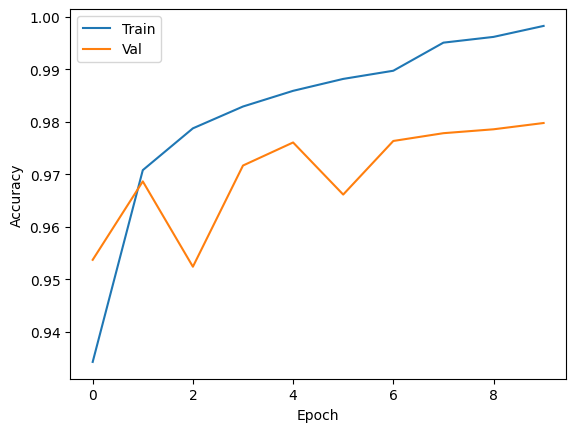

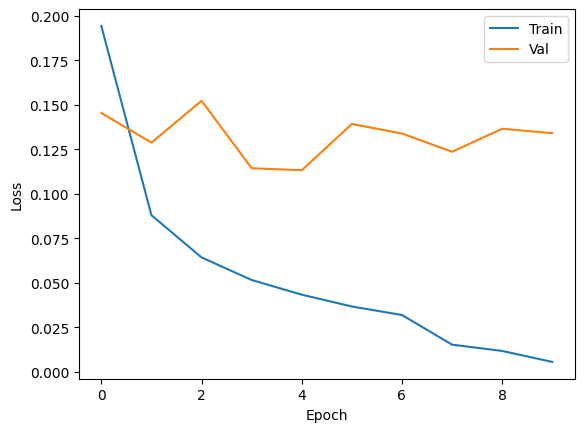

In [10]:
y_val_pred = np.argmax(model.predict(X_val_final, verbose=0), axis=1)
y_val_true = y_val

print("Validation MCC:", matthews_corrcoef(y_val_true, y_val_pred))

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


Test Accuracy: 0.9749223589897156
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     18118
           1       0.72      0.72      0.72       556
           2       0.95      0.92      0.94      1448
           3       0.77      0.82      0.80       162
           4       0.99      0.98      0.98      1608

    accuracy                           0.97     21892
   macro avg       0.88      0.89      0.89     21892
weighted avg       0.97      0.97      0.97     21892

Specificity : 0.9833


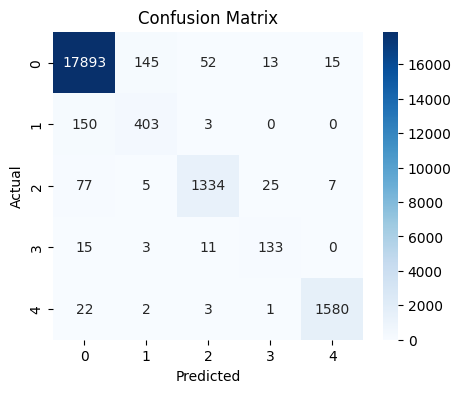

Training Accuracy   : 0.9893
Validation Accuracy : 0.9761
Testing Accuracy    : 0.9749
Training Loss       : 0.0305
Validation Loss     : 0.1133
Testing Loss        : 0.1305
Testing MCC         : 0.9173


In [12]:
#test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
test_loss, test_acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)
print("Test Accuracy:", test_acc)

y_test_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
specificities = []

for i in range(N_CLASSES):

    tp = cm[i, i]

    fp = cm[:, i].sum() - tp

    fn = cm[i, :].sum() - tp

    tn = cm.sum() - tp - fp - fn

    specificity_i = tn / (
        tn + fp + 1e-8
    )

    specificities.append(
        specificity_i
    )

specificity = np.mean(
    specificities
)

print(
    f"Specificity : {specificity:.4f}"
)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

train_loss, train_acc = model.evaluate(
    X_train_final,
    y_train_final,
    verbose=0
)

val_loss, val_acc = model.evaluate(
    X_val_final,
    y_val,
    verbose=0
)

test_loss, test_acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)
test_mcc = matthews_corrcoef(y_test, y_test_pred)

print(f"Training Accuracy   : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Testing Accuracy    : {test_acc:.4f}")

print(f"Training Loss       : {train_loss:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")
print(f"Testing Loss        : {test_loss:.4f}")

print(f"Testing MCC         : {test_mcc:.4f}")
